In [ ]:
import os
from pathlib import Path


from aereo.backends import LocalProcessBackend
from aereo.client import AereoClient
from aereo.pipeline import ExtractionJob


DRY_RUN = os.environ.get("DRY_RUN", "false").lower() in ("1", "true", "yes")
job = ExtractionJob.load_from_config(
    config_dir=(Path(".").parent / "config").resolve(),
    config_name="job_ndvi.yaml",
)

In [3]:
def run_pipeline(job: ExtractionJob) -> None:
    """Run search → prepare → extract for a validated job.

    Args:
        job: The validated ``ExtractionJob`` to execute.
    """
    client = AereoClient()

    # Search
    print("\n🔍 Searching...")
    search_results = client.search(job.search)
    print(f"✓ Found {len(search_results)} scenes")

    if search_results.empty:
        print("No results; skipping prepare/extract.")
        return

    # Prepare
    print("\n📦 Preparing tasks...")
    tasks = client.prepare_tasks(
        search_results=search_results,
        job=job,
        cells_per_task=50,
    )
    print(f"✓ Prepared {len(tasks)} tasks")

    # Extract
    print("\n⛏️ Extracting...")
    backend = LocalProcessBackend(max_workers=4)
    artifacts = client.execute_tasks(tasks, backend=backend)
    print(f"✓ Extracted {len(artifacts)} artifacts")
    return artifacts

In [4]:
artifacts = run_pipeline(job)


🔍 Searching...
2026-06-13 16:16:51 [info     ] search_called                  provider=SearchSTAC
✓ Found 16 scenes

📦 Preparing tasks...
✓ Prepared 4 tasks

⛏️ Extracting...
2026-06-13 16:16:52 [info     ] execute_tasks_start            backend=LocalProcessBackend failure_mode=strict task_count=4
✓ Extracted 125 artifacts


In [8]:
artifacts.iloc[120].uri

'/tmp/aereo_extraction/job-sentinel2_sample/loc-428D601L/date-20240110/loc-428D601L_start-20240110T142711_end-20240110T142711_job-sentinel2_sample_collection-sentinel-2-l2a_variable-B08+B04_res-10000m.tif'

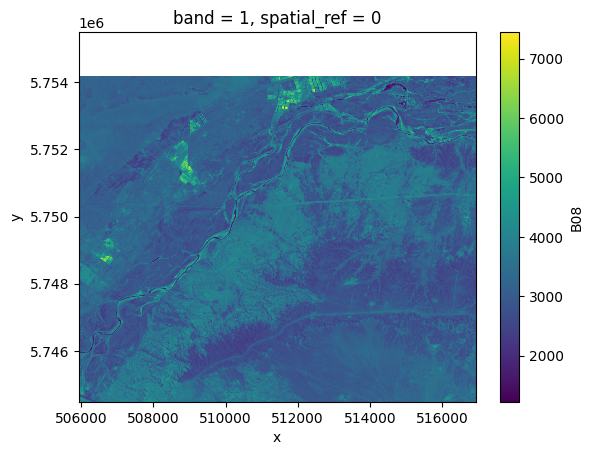

In [7]:
import rioxarray

rioxarray.open_rasterio(artifacts.iloc[120].uri)[0].plot()